# <font color="brown">**Heritage Institute of Technology**
# <font color="brown">**Department of AEIE**
# <font color="brown">**MACHINE LEARNING TECHNIQUES LAB (AEI3262)**
# <font color="brown">**B. Tech AEIE,   6th Semester**
# <font color="Blue">**Experiment No. 9: Image Classification using Convolutional Neural Networks </font>**  **[CO: AEI3262.4]**


# <font color="Blue">**Objective:**

- To train a CNN model for classification using MNIST or CIFAR-10 dataset.
- To tune hyperparameters (filter size, depth, pooling, etc.).
- To Display training curves, confusion matrix, performance metrices and visualizations of predictions vs. ground truth.


# <font color="Blue"> **A: Learning Outcome:**
## After completion of this assignment you will be able to:

*  Apply CNN models on a given image data set.
*  Learn how to find optimal model architecture.
*  Perform hyperparameter btuning.
*  Assess the performance of the model.


# <font color="Blue">**B. Instructions:**
* You will be using Python 3.
* Avoid using for-loops and while-loops, unless you are explicitly told to do so.
* Do not modify the function name, variable names, comments in cells.
* Write your code where it is asked to write.
* After your coding, run the cell and see your results.

# <font color="Blue">**C. Useful PYTHON Commands**
Some useful PYTHON commands that may be required to perform this experiment are given below:
# <font color="magenta">*Requird Library:*
    numpy     pands    sklearn    matplotlib.pyplot

# <font color="magenta"> *Elementary Functions from numpy:*
    np.unique()       

# <font color="magenta">*Functions from matplotlib.pyplot:*
    plt.figure()   plt.plot()     plt.scatter()  plt.title()
    plt.xlabel()   plt.ylabel()   plt.xticks()   plt.yticks()  
    plt.legend()   plt.grid()     plt.show()     plt.text()
    plt.bar()     

# <font color="magenta"> *Elementary Functions from Seaborn:*
    sns.heatmap()

# <font color="magenta">*Modules and Methods of sklearn library:*
    sklearn.preprocessing.MinMaxScaler()
    scaler.transform()
   
    model.fit()
    model.predict()
    sklearn.model_selection.train_test_split()
    sklearn.metrics.confusion_matrix, accuracy_score, precision_score, recall_score
  

    from tensorflow.keras.datasets import mnist
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.regularizers import l2


##<font color="blue"> **Problem-1:**</font> Implement a Convolutional Neural Network (CNN) for image classification using a suitable dataset (e.g., MNIST Dataset or CIFAR-10 Dataset) using TensorFlow/Keras.

i)	Load the dataset and perform preprocessing:

-  Normalize pixel values (e.g., scale to [0,1])
-  Reshape data to appropriate format (e.g., 28×28×1 or 32×32×3)
-  Convert target labels into categorical format (one-hot encoding)

ii)	Split the dataset into training and testing sets (if not pre-split).

iii)	Design and implement a CNN model consisting of:

-	Convolutional layers
-	Activation functions (ReLU)
-	Pooling layers (MaxPooling)
-	Fully connected (Dense) layers
-	Output layer with suitable activation (Softmax)

iv)	Train the CNN model using appropriate:
-	Loss function (categorical crossentropy)
-	Optimizer (Adam or SGD)
-	Batch size and number of epochs

v)	Tune hyperparameters by varying:
-	Number of convolutional layers
-	Filter size and number of filters
-	Pooling size
-	Batch size and epochs

vi)	Plot training and validation:
-	Accuracy curves
-	Loss curves

vii)	Evaluate the trained model on the test dataset and compute:
-	Accuracy
-	Precision
-	Recall
-	F1-score

viii)	Display the confusion matrix of the model.

ix)	Visualize model predictions by comparing:
-	Predicted labels
-	Ground truth labels for a subset of test images.

x)	Analyze the effect of hyperparameter tuning on model performance and summarize the observations.



# <font color="magenta"> **Import Libraries:**


In [1]:
# ==============================
# Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix

# <font color="magenta"> **Load & Preprocess Data:**


In [2]:
# ==============================
# Load & Preprocess Data
# ==============================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape (28x28x1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# <font color="magenta"> **Define CNN Model:**


In [3]:
# ==============================
# Define CNN Model
# ==============================
model = Sequential([

    # Convolution Block 1
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Convolution Block 2
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# <font color="magenta"> **Compile & Train Model:**

In [4]:
# ==============================
# Compile Model
# ==============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Early Stopping
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ==============================
# Train Model
# ==============================
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8944 - loss: 0.5341 - val_accuracy: 0.9757 - val_loss: 0.2424
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9585 - loss: 0.2773 - val_accuracy: 0.9834 - val_loss: 0.1863
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9649 - loss: 0.2372 - val_accuracy: 0.9817 - val_loss: 0.1833
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9680 - loss: 0.2251 - val_accuracy: 0.9849 - val_loss: 0.1712
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9686 - loss: 0.2165 - val_accuracy: 0.9837 - val_loss: 0.1665
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9696 - loss: 0.2133 - val_accuracy: 0.9777 - val_loss: 0.1811
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9712 - loss: 0.2062 - val_accuracy: 0.9846 - val_loss: 0.1610
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9731 - loss: 0.2009 - val_acc

# <font color="magenta"> **Accuracy Curves:**

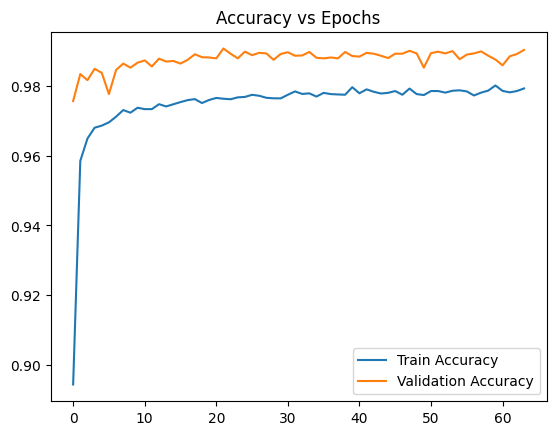

In [7]:
# ==============================
# Accuracy Curves
# ==============================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()



# <font color="magenta"> **Loss Curves:**

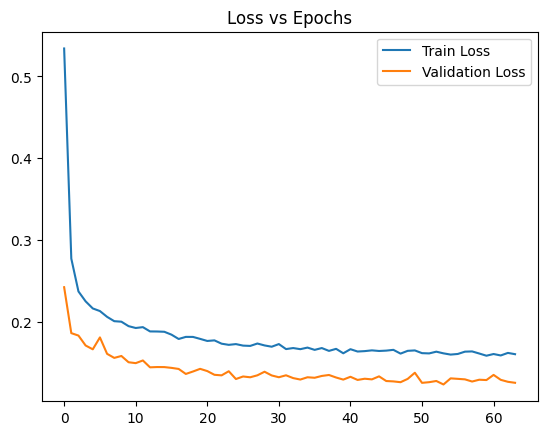

In [8]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

# <font color="magenta"> **Model Evaluation & Confusion Matrix:**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



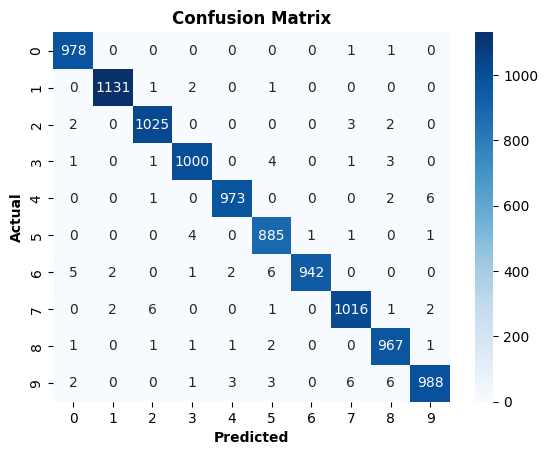

In [11]:
# ==============================
# Evaluation
# ==============================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

# ==============================
# Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')
plt.show()



# <font color="magenta"> **Predictions vs Ground Truth:**

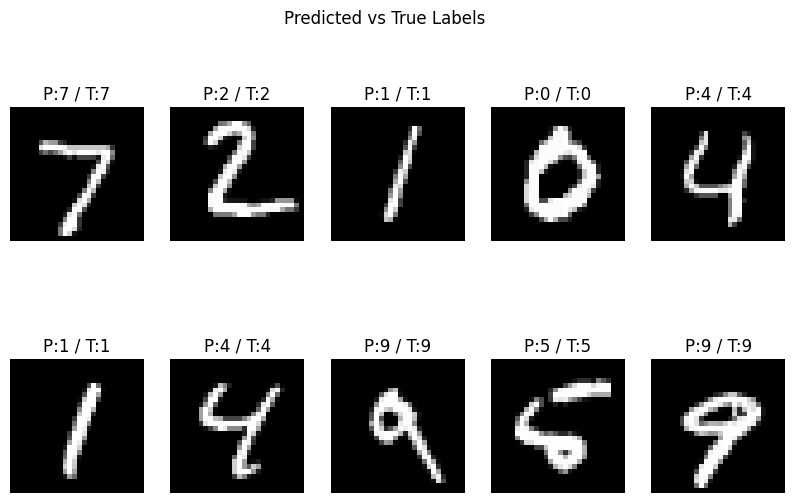


Final Test Accuracy: 0.9905


In [10]:
# ==============================
# Predictions vs Ground Truth
# ==============================
plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred_classes[i]} / T:{y_test[i]}")
    plt.axis('off')

plt.suptitle("Predicted vs True Labels")
plt.show()

# ==============================
# Final Test Accuracy
# ==============================
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nFinal Test Accuracy: {acc:.4f}")

# <font color="green"> **Assignment:**
Implement a Convolutional Neural Network (CNN) for image classification using either Fashion-MNIST dataset or CIFAR-10 Dataset and carryout all the steps as shown in above CNN example.